In [1]:
# Simulação FSK Binário — Geração e Recepção

#   1. Parâmetros do sistema
#   2. Geração dos bits e do sinal FSK modulado
#   3. Canal AWGN — adição de ruído gaussiano branco
#   4. Receptor FSK coerente por correlação (filtro casado)
#   5. Cálculo da BER simulada e teórica
#   6. Geração dos gráficos


!pip install numpy matplotlib scipy

Eb/N0 = 6.0 dB
Bits TX  : [0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1]
Bits RX  : [0 1 0 1 1 1 1 0 0 0 1 1 0 1 0 1]
Erros    : 1 de 16 bits
Eb/N0 =   0.0 dB | BER sim = 1.542e-01 | BER teo = 1.587e-01
Eb/N0 =   1.0 dB | BER sim = 1.282e-01 | BER teo = 1.309e-01
Eb/N0 =   2.0 dB | BER sim = 1.044e-01 | BER teo = 1.040e-01
Eb/N0 =   3.0 dB | BER sim = 7.860e-02 | BER teo = 7.890e-02
Eb/N0 =   4.0 dB | BER sim = 5.820e-02 | BER teo = 5.650e-02
Eb/N0 =   5.0 dB | BER sim = 3.880e-02 | BER teo = 3.768e-02
Eb/N0 =   6.0 dB | BER sim = 2.480e-02 | BER teo = 2.301e-02
Eb/N0 =   7.0 dB | BER sim = 1.220e-02 | BER teo = 1.259e-02
Eb/N0 =   8.0 dB | BER sim = 4.800e-03 | BER teo = 6.004e-03
Eb/N0 =   9.0 dB | BER sim = 1.400e-03 | BER teo = 2.413e-03
Eb/N0 =  10.0 dB | BER sim = 2.000e-04 | BER teo = 7.827e-04
Eb/N0 =  11.0 dB | BER sim = 4.000e-04 | BER teo = 1.940e-04
Eb/N0 =  12.0 dB | BER sim = 2.000e-04 | BER teo = 3.430e-05
Eb/N0 =  13.0 dB | BER sim = 0.000e+00 | BER teo = 3.969e-06
Eb/N0 =  14.0 dB 

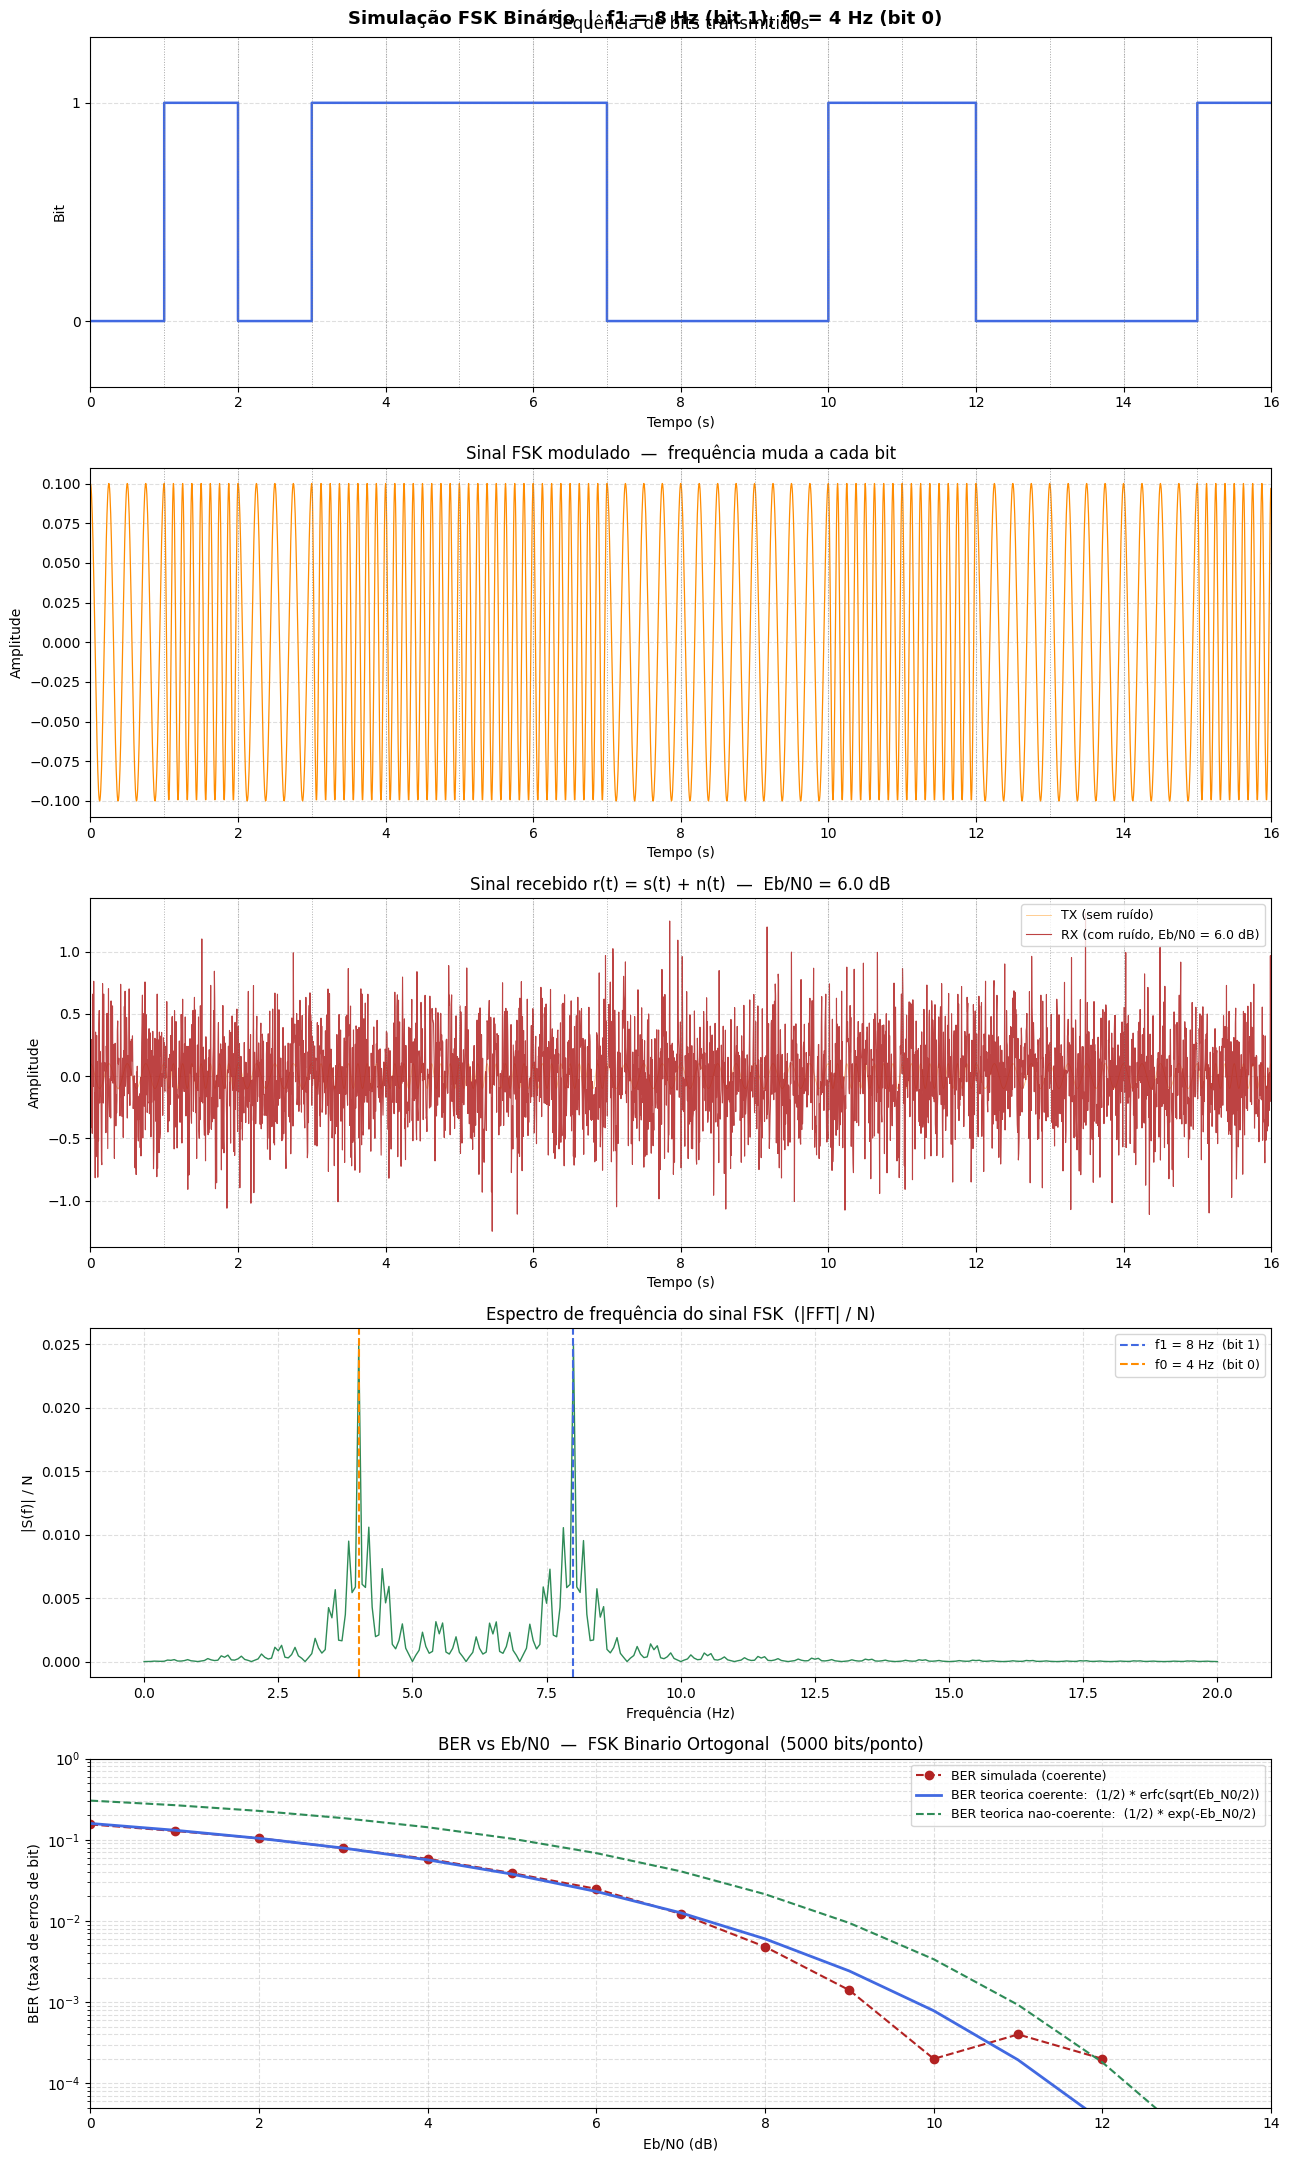

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

Nbit  = 16       # bits para visualização do sinal no tempo
N_ber = 5000     # bits por ponto de Eb/N0 para cálculo da BER

# Parâmetros temporais e espectrais
fs  = 200        # taxa de amostragem (Hz)
Tb  = 1.0        # duração de cada bit (s)
Ns  = int(fs * Tb)   # amostras por bit: Ns = 200

# Frequências das portadoras:
#   bit 1 → senoide em f1 Hz  (8 ciclos completos por bit)
#   bit 0 → senoide em f0 Hz  (4 ciclos completos por bit)
#
# Condição de ortogonalidade FSK: (f1 - f0) * Tb = inteiro
#   (8 - 4) * 1 = 4  →  portadoras são ortogonais  ✓
f1 = 8.0   # Hz — portadora do bit 1
f0 = 4.0   # Hz — portadora do bit 0

# Amplitude normalizada para energia de bit unitária (Eb = 1):
#   Energia discreta de uma senoide amostrada:
#     Eb = sum_{k=0}^{Ns-1} [A*cos(2πf*k/fs)]^2 = A^2 * Ns/2
#   Para Eb = 1: A = sqrt(2/Ns)
Ampl = np.sqrt(2.0 / Ns)   # Ampl ≈ 0.1 com Ns=200

# Vetor de tempo de um único bit (amostras de 0 até Tb)
t_bit = np.arange(Ns) / fs

# Portadoras de referência (usadas tanto no modulador quanto no receptor)
ref1 = Ampl * np.cos(2 * np.pi * f1 * t_bit)   # referência para bit 1
ref0 = Ampl * np.cos(2 * np.pi * f0 * t_bit)   # referência para bit 0



np.random.seed(7)   # semente fixa para reprodutibilidade

# Sequência de bits aleatórios
# bits[i] ∈ {0, 1} com probabilidade 0.5 cada (sorteio de Bernoulli)
bits = (np.random.rand(Nbit) > 0.5).astype(int)

# Modulação FSK símbolo a símbolo
# Para cada bit i:
#   se bits[i] == 1 → copia ref1 no trecho [i*Ns : (i+1)*Ns] do sinal
#   se bits[i] == 0 → copia ref0 no mesmo trecho
#
# O resultado é um sinal contínuo com mudança de frequência a cada bit.

sinal_fsk = np.zeros(Nbit * Ns)

for i, bit in enumerate(bits):
    inicio = i * Ns
    fim    = inicio + Ns
    sinal_fsk[inicio:fim] = ref1 if bit == 1 else ref0

# Vetor de tempo global e forma de onda dos bits (para plotagem)
t_total    = np.arange(len(sinal_fsk)) / fs
bits_forma = np.repeat(bits, Ns).astype(float)


# O canal AWGN adiciona ruído n[k] ~ N(0, σ²) independente em cada amostra.
#
# Relação entre σ² e Eb/N0:
#   N0 = Eb / (Eb/N0)    →   σ² = N0/2 = Eb / (2 * Eb_N0_lin)
#
# Com Eb = 1 (normalizado):
#   σ² = 1 / (2 * Eb_N0_lin)

Eb_N0_dB_vis  = 6.0                              # Eb/N0 para visualização (dB)
Eb_N0_lin_vis = 10 ** (Eb_N0_dB_vis / 10.0)     # conversão para escala linear

sigma2_vis = 1.0 / (2.0 * Eb_N0_lin_vis)        # variância do ruído por amostra
sigma_vis  = np.sqrt(sigma2_vis)

ruido_vis       = sigma_vis * np.random.randn(len(sinal_fsk))
sinal_recebido  = sinal_fsk + ruido_vis


# RECEPTOR FSK COERENTE POR CORRELAÇÃO

# O receptor coerente compara as correlações do sinal recebido com cada portadora.
#
# Para o i-ésimo bit, com o sinal recebido r[k] no intervalo [i*Ns : (i+1)*Ns]:
#
#   R1 = Σ_{k=0}^{Ns-1}  r[k] * ref1[k]    (correlação com portadora de f1)
#   R0 = Σ_{k=0}^{Ns-1}  r[k] * ref0[k]    (correlação com portadora de f0)
#
# Regra de decisão (máxima verossimilhança):
#   bit detectado = 1  se  R1 > R0
#   bit detectado = 0  se  R0 ≥ R1


def receptor_fsk(sinal, ref1, ref0, Ns):
    """
    Detecta bits de um sinal FSK usando correlação coerente.

    Parâmetros
    ----------
    sinal : ndarray, shape (Nbit*Ns,)
        Sinal recebido (portadora + ruído).
    ref1, ref0 : ndarray, shape (Ns,)
        Portadoras de referência normalizadas (Eb=1) para bit 1 e bit 0.
    Ns : int
        Número de amostras por bit.

    Retorna
    -------
    bits_rx : ndarray de int, shape (Nbit,)
        Sequência de bits decidida pelo receptor.
    """
    num_bits      = len(sinal) // Ns
    sinal_matrix  = sinal[:num_bits * Ns].reshape(num_bits, Ns)  # (Nbit, Ns)
    R1 = sinal_matrix @ ref1   # correlação de cada bit com portadora de f1
    R0 = sinal_matrix @ ref0   # correlação de cada bit com portadora de f0
    return (R1 > R0).astype(int)   # decide bit 1 onde R1 > R0

bits_rx_vis = receptor_fsk(sinal_recebido, ref1, ref0, Ns)

erros_vis = int(np.sum(bits != bits_rx_vis))
print(f"Eb/N0 = {Eb_N0_dB_vis} dB")
print(f"Bits TX  : {bits}")
print(f"Bits RX  : {bits_rx_vis}")
print(f"Erros    : {erros_vis} de {Nbit} bits")


# BER SIMULADA vs TEÓRICA

# Varia Eb/N0 de 0 a 14 dB e calcula a BER simulada ponto a ponto.
#
# BER teórica FSK coerente (ortogonal, AWGN):
#   Pe_coe = Q(sqrt(Eb/N0))  =  (1/2) * erfc( sqrt(Eb_N0_lin / 2) )
#
#   Derivação:
#     Variável de decisão: d = R1 - R0
#     Sob H1:  d ~ N(Eb, 2*σ²*Eb)  com σ² = 1/(2*Eb_N0_lin) e Eb=1
#             → d ~ N(1, 1/Eb_N0_lin)
#     P(erro) = P(d < 0) = Q( sqrt(Eb_N0_lin) )
#             = (1/2) * erfc( sqrt(Eb_N0_lin/2) )
#
# BER teórica FSK não-coerente (ortogonal, AWGN):
#   Pe_nco = (1/2) * exp(-Eb_N0_lin / 2)


Eb_N0_dB_vec  = np.arange(0, 15, 1)
Eb_N0_lin_vec = 10 ** (Eb_N0_dB_vec / 10.0)

ber_coe = 0.5 * erfc(np.sqrt(Eb_N0_lin_vec / 2.0))
ber_nco = 0.5 * np.exp(-Eb_N0_lin_vec / 2.0)

ber_sim = []
np.random.seed(0)

for Eb_N0_lin in Eb_N0_lin_vec:

    # --- Gera N_ber bits aleatórios ---
    bits_sim = (np.random.rand(N_ber) > 0.5).astype(int)

    # --- Modulação FSK (vetorizada sem laço explícito) ---
    # mask1/mask0: (N_ber, 1) — seleciona qual portadora usar em cada linha
    mask1    = (bits_sim == 1).astype(float).reshape(-1, 1)
    mask0    = (bits_sim == 0).astype(float).reshape(-1, 1)
    simbolos = mask1 * ref1 + mask0 * ref0   # (N_ber, Ns)

    # --- Canal AWGN ---
    # σ² = 1/(2*Eb_N0_lin) pois Eb=1 (normalizado)
    sigma = np.sqrt(1.0 / (2.0 * Eb_N0_lin))
    ruido = sigma * np.random.randn(N_ber, Ns)
    r     = simbolos + ruido   # (N_ber, Ns)

    # --- Receptor coerente (correlação vetorizada) ---
    R1          = r @ ref1   # (N_ber,)
    R0          = r @ ref0   # (N_ber,)
    bits_rx_sim = (R1 > R0).astype(int)

    # --- BER do ponto ---
    num_erros = np.sum(bits_sim != bits_rx_sim)
    ber_ponto = num_erros / N_ber
    ber_sim.append(ber_ponto)

    print(f"Eb/N0 = {10*np.log10(Eb_N0_lin):5.1f} dB | "
          f"BER sim = {ber_ponto:.3e} | "
          f"BER teo = {0.5*erfc(np.sqrt(Eb_N0_lin/2)):.3e}")

ber_sim = np.array(ber_sim)


# GRÁFICOS


fig, axes = plt.subplots(5, 1, figsize=(13, 22))
fig.suptitle("Simulação FSK Binário  |  f1 = 8 Hz (bit 1), f0 = 4 Hz (bit 0)",
             fontsize=13, fontweight='bold')

# ---- Gráfico 1: Sequência de bits transmitidos ----
ax = axes[0]
ax.step(t_total, bits_forma, where='post', color='royalblue', linewidth=1.8)
for i in range(1, Nbit):
    ax.axvline(x=i * Tb, color='gray', linestyle=':', linewidth=0.7, alpha=0.7)
ax.set_title("Sequência de bits transmitidos")
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Bit")
ax.set_ylim(-0.3, 1.3)
ax.set_yticks([0, 1])
ax.set_xlim(0, Nbit * Tb)
ax.grid(True, linestyle='--', alpha=0.4)

# ---- Gráfico 2: Sinal FSK modulado ----
ax = axes[1]
ax.plot(t_total, sinal_fsk, color='darkorange', linewidth=0.9)
for i in range(1, Nbit):
    ax.axvline(x=i * Tb, color='gray', linestyle=':', linewidth=0.7, alpha=0.7)
ax.set_title("Sinal FSK modulado  —  frequência muda a cada bit")
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, Nbit * Tb)
ax.grid(True, linestyle='--', alpha=0.4)

# ---- Gráfico 3: Sinal recebido com ruído AWGN ----
ax = axes[2]
ax.plot(t_total, sinal_fsk, color='darkorange', linewidth=0.6,
        alpha=0.5, label='TX (sem ruído)')
ax.plot(t_total, sinal_recebido, color='firebrick', linewidth=0.8,
        alpha=0.85, label=f'RX (com ruído, Eb/N0 = {Eb_N0_dB_vis} dB)')
for i in range(1, Nbit):
    ax.axvline(x=i * Tb, color='gray', linestyle=':', linewidth=0.7, alpha=0.6)
ax.set_title(f"Sinal recebido r(t) = s(t) + n(t)  —  Eb/N0 = {Eb_N0_dB_vis} dB")
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, Nbit * Tb)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# ---- Gráfico 4: Espectro de frequência (FFT do sinal FSK) ----
ax = axes[3]
N_fft    = len(sinal_fsk)
espectro = np.abs(np.fft.fft(sinal_fsk)) / N_fft
freqs    = np.fft.fftfreq(N_fft, d=1.0 / fs)

idx_pos = (freqs >= 0) & (freqs <= 20)
ax.plot(freqs[idx_pos], espectro[idx_pos], color='seagreen', linewidth=1.0)
ax.axvline(x=f1, color='royalblue', linestyle='--', linewidth=1.5,
           label=f'f1 = {f1:.0f} Hz  (bit 1)')
ax.axvline(x=f0, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'f0 = {f0:.0f} Hz  (bit 0)')
ax.set_title("Espectro de frequência do sinal FSK  (|FFT| / N)")
ax.set_xlabel("Frequência (Hz)")
ax.set_ylabel("|S(f)| / N")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# ---- Gráfico 5: BER simulada vs teórica ----
ax = axes[4]
mask = ber_sim > 0
ax.semilogy(Eb_N0_dB_vec[mask], ber_sim[mask],
            'o--', color='firebrick', linewidth=1.5,
            markersize=6, label='BER simulada (coerente)')
ax.semilogy(Eb_N0_dB_vec, ber_coe, '-', color='royalblue', linewidth=2.0,
            label='BER teorica coerente:  (1/2) * erfc(sqrt(Eb_N0/2))')
ax.semilogy(Eb_N0_dB_vec, ber_nco, '--', color='seagreen', linewidth=1.5,
            label='BER teorica nao-coerente:  (1/2) * exp(-Eb_N0/2)')
ax.set_title(f"BER vs Eb/N0  —  FSK Binario Ortogonal  ({N_ber} bits/ponto)")
ax.set_xlabel("Eb/N0 (dB)")
ax.set_ylabel("BER (taxa de erros de bit)")
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 14)
ax.set_ylim(5e-5, 1.0)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("/content/fsk_resultado.png", dpi=150, bbox_inches='tight')
plt.show()
